# NBA Player Performance Analysis (2010–2020)

This project analyzes NBA player statistics between 2010 and 2020.

The analysis focuses on:
- Physical attributes and performance
- Draft position and player success
- NBA performance trends
- Geographic distribution of top scorers

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
path = 'D:\\Data4Analytics\\'
df = pd.read_csv(path + 'players_stats_by_season_full_details.csv')

In [5]:
# Filter data for the 2010–2020 period (modern NBA era).
seasons_to_keep = [
    '2010 - 2011', '2011 - 2012', '2012 - 2013', '2013 - 2014',
    '2014 - 2015', '2015 - 2016', '2016 - 2017', '2017 - 2018',
    '2018 - 2019', '2019 - 2020'
]
df = df[df['Season'].isin(seasons_to_keep)].copy()

print(sorted(df['Season'].unique()))
print(len(df))

['2010 - 2011', '2011 - 2012', '2012 - 2013', '2013 - 2014', '2014 - 2015', '2015 - 2016', '2016 - 2017', '2017 - 2018', '2018 - 2019', '2019 - 2020']
42913


In [6]:
# Perform data cleaning and create three categorical variables for analysis.

df['height_cm'] = pd.to_numeric(df['height_cm'], errors='coerce')
df['weight_kg'] = pd.to_numeric(df['weight_kg'], errors='coerce')

df['performance_tier'] = pd.cut(
    df['PTS'],
    bins=[-1, 5, 10, 20, 100],
    labels=['Below Average', 'Average', 'Good', 'Elite']
)

df['size_category'] = pd.cut(
    df['height_cm'],
    bins=[0, 185, 200, 230],
    labels=['Guard', 'Forward', 'Center']
)

df['draft_tier'] = pd.cut(
    df['draft_pick'],
    bins=[0, 5, 15, 30],
    labels=['Top 5', 'Lottery', 'Late 1st Round']
)

print(df['performance_tier'].value_counts())
print(df['size_category'].value_counts())
print(df['draft_tier'].value_counts())

Elite            6290
Good              421
Average           160
Below Average      83
Name: performance_tier, dtype: int64
Forward    19432
Center     17921
Guard       5486
Name: size_category, dtype: int64
Late 1st Round    2707
Lottery           1862
Top 5             1202
Name: draft_tier, dtype: int64


# Physical Attributes vs Performance

This section examines the relationship between player physical characteristics and on-court performance.

The analysis focuses on points, rebounds and assists across different size categories.

In [7]:
# PHYSICAL ATTRIBUTES vs PERFORMANCE
df_physical = df[df['height_cm'].notna() & df['weight_kg'].notna()].copy()
# Metrics.
print(df_physical.groupby('size_category', observed=True)['PTS'].mean().round(2))
print(df_physical.groupby('size_category', observed=True)['REB'].mean().round(2))
print(df_physical.groupby('size_category', observed=True)['AST'].mean().round(2))
print(df_physical.groupby('performance_tier', observed=True)['height_cm'].mean().round(1))

size_category
Guard      322.78
Forward    303.14
Center     320.37
Name: PTS, dtype: float64
size_category
Guard       80.07
Forward     97.75
Center     165.34
Name: REB, dtype: float64
size_category
Guard      112.52
Forward     70.57
Center      42.85
Name: AST, dtype: float64
performance_tier
Below Average    195.2
Average          195.9
Good             197.3
Elite            197.6
Name: height_cm, dtype: float64


FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Data4Analytics\\section1_physical_performance.png'

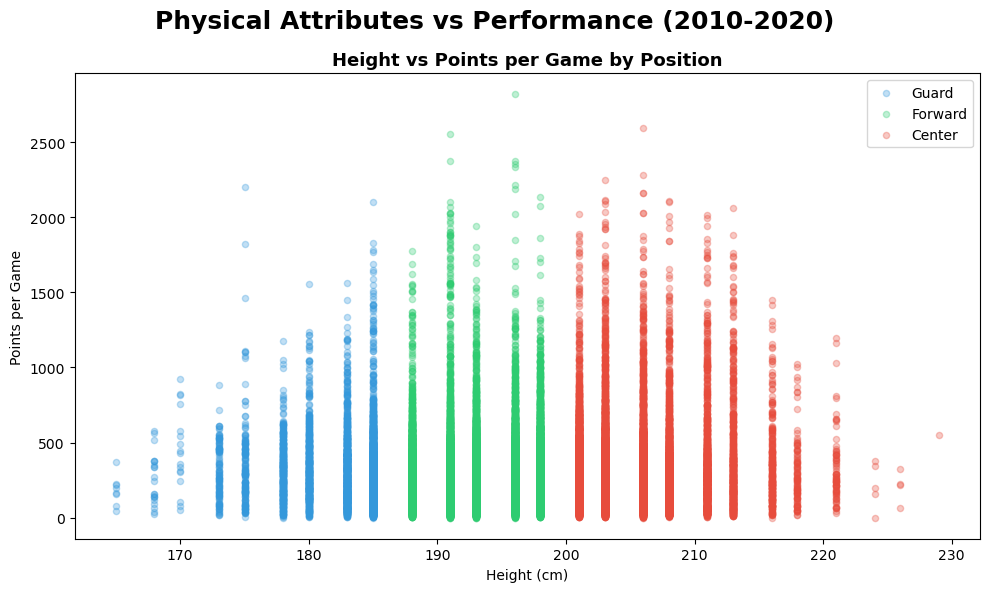

In [8]:
# Charts
# Scatter plot analyzing the relationship between player height and scoring performance.
# The visualization shows that guards are typically shorter but more productive in scoring.
# Centers dominate in rebounds due to height advantage, while guards lead in points and assists.

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
fig.suptitle('Physical Attributes vs Performance (2010-2020)', fontsize=18, fontweight='bold')

colors_size = {'Guard': '#3498DB', 'Forward': '#2ECC71', 'Center': '#E74C3C'}
for size, color in colors_size.items():
    subset = df_physical[df_physical['size_category'] == size]
    ax.scatter(subset['height_cm'], subset['PTS'],
               label=size, color=color, alpha=0.3, s=20)

ax.set_title('Height vs Points per Game by Position', fontsize=13, fontweight='bold')
ax.set_xlabel('Height (cm)')
ax.set_ylabel('Points per Game')
ax.legend()

plt.tight_layout()
plt.savefig(path + 'section1_physical_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# Draft Position Analysis

This section investigates whether draft position is associated with future player performance.

Players are grouped into different draft tiers and compared using scoring and playing time statistics.

In [ ]:
# DRAFT ANALYSIS
df_draft = df[df['draft_pick'].notna()].copy()
# Metrics.
print(df_draft.groupby('draft_tier', observed=True)['PTS'].mean().sort_values(ascending=False).round(2))
print(df_draft.groupby('draft_tier', observed=True)['MIN'].mean().sort_values(ascending=False).round(2))
print(df_draft.groupby('draft_pick')['PTS'].mean().head(10).round(2))

top_drafted = df_draft.groupby('Player').agg(
    draft_pick=('draft_pick', 'first'),
    avg_pts=('PTS', 'mean'),
    avg_min=('MIN', 'mean')
).dropna().sort_values('avg_pts', ascending=False).head(10)
print(top_drafted.round(2))

In [ ]:
# Charts
# Chart 2a: Bar chart showing whether the #1 draft pick is truly the best performer.
# Chart 2b: Stacked bar chart showing the percentage of players in each draft tier
# (Below Average, Average, Good, Elite).

# In the first chart, Top 5 picks show on average 211 more points than Late 1st Round picks.
# The #1 draft pick does not always guarantee the best performance — there are hidden gems
# even among picks 15–30.

# In the second chart, we observe the distribution of performance tiers:
# Top 5 picks have a higher proportion of Elite players.

# Conclusion: draft position matters, but it is not an absolute guarantee of success.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Draft Analysis: Does Draft Position Matter? (2010-2020)',
             fontsize=18, fontweight='bold')

draft_pts = df_draft[df_draft['draft_pick'] <= 30].groupby('draft_pick')['PTS'].mean()
axes[0].bar(draft_pts.index, draft_pts.values, color='#3498DB', edgecolor='white')
axes[0].set_title('Avg Points by Draft Pick (Top 30)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Draft Pick Number')
axes[0].set_ylabel('Average Points per Game')
axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Top 5 cutoff')
axes[0].axvline(x=15, color='orange', linestyle='--', alpha=0.7, label='Lottery cutoff')
axes[0].legend()

draft_perf = df_draft.groupby(['draft_tier', 'performance_tier'], observed=True).size().unstack(fill_value=0)
draft_perf_pct = draft_perf.div(draft_perf.sum(axis=1), axis=0) * 100
draft_perf_pct.plot(kind='bar', ax=axes[1],
                    color=['#E74C3C', '#F39C12', '#2ECC71', '#9B59B6'],
                    edgecolor='white')
axes[1].set_title('Performance Distribution by Draft Tier (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Draft Tier')
axes[1].set_ylabel('Percentage of Players (%)')
axes[1].legend(title='Performance', fontsize=9)
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig(path + 'section2_draft_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# NBA Performance Analysis

This section focuses exclusively on NBA players and examines overall performance trends and player quality distribution.

In [ ]:
# NBA ANALYSIS
df_leagues = df[df['League'] == 'NBA'].copy()
# Metrics. 
print(df_leagues.groupby('League', observed=True)['PTS'].mean().round(2))
print(df_leagues.groupby('League', observed=True)['MIN'].mean().round(2))
print(df_leagues.groupby('League', observed=True)['height_cm'].mean().round(1))

top_nat = df_leagues['nationality'].value_counts().head(3)
print(top_nat)

In [ ]:
# Charts
# Chart 3a: Bar chart showing average NBA player statistics.
# Chart 3b: Distribution of player quality in the NBA.

# The NBA is the most competitive basketball league in the world.
# On average, a player scores around 540 points per season.

# The second chart shows the distribution of player quality,
# indicating how many players fall into Elite, Good, Average, and Below Average categories.

# This highlights the competitiveness of the NBA, where even "Average" players
# are among the best basketball players in the world.

# Conclusion: The 2010–2020 NBA era represents a balance between elite stars
# and role players.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('NBA Analysis: Stats & Player Quality (2010-2020)',
             fontsize=18, fontweight='bold')

league_stats = df_leagues.groupby('League', observed=True)[['PTS', 'REB', 'AST']].mean()
league_stats.plot(kind='bar', ax=axes[0],
                  color=['#E74C3C', '#3498DB', '#2ECC71'],
                  edgecolor='white')
axes[0].set_title('NBA Avg Stats (2010-2020)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Average per Game')
axes[0].legend(['Points', 'Rebounds', 'Assists'])
plt.xticks(rotation=0)

league_perf = df_leagues.groupby(['League', 'performance_tier'], observed=True).size().unstack(fill_value=0)
league_perf_pct = league_perf.div(league_perf.sum(axis=1), axis=0) * 100
league_perf_pct.plot(kind='bar', ax=axes[1],
                     color=['#E74C3C', '#F39C12', '#2ECC71', '#9B59B6'],
                     edgecolor='white')
axes[1].set_title('NBA Player Quality Distribution (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('NBA')
axes[1].set_ylabel('Percentage of Players (%)')
axes[1].legend(title='Performance Tier', fontsize=9)
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(path + 'section3_nba_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# SUMMARY

best_scoring_position = df_physical.groupby('size_category', observed=True)['PTS'].mean().idxmax()
best_rebounding_position = df_physical.groupby('size_category', observed=True)['REB'].mean().idxmax()
print(best_scoring_position)
print(best_rebounding_position)

top5_avg = df_draft[df_draft['draft_tier'] == 'Top 5']['PTS'].mean()
late_avg = df_draft[df_draft['draft_tier'] == 'Late 1st Round']['PTS'].mean()
print(round(top5_avg, 2))
print(round(late_avg, 2))
print(round(top5_avg - late_avg, 2))

nba_avg = df_leagues['PTS'].mean()
print(round(nba_avg, 2))

In [ ]:
print(df.columns.tolist())
print(df['Stage'].unique())

# Top Scorers Analysis

The objective of this section is to identify the highest-scoring players during the 2010–2020 period.

Regular season and playoff performances are analyzed separately using points per game (PPG).

In [ ]:
df_modern = df

In [ ]:
df_modern_top_scorers_regular_season = df_modern[df_modern['Stage'] == 'Regular_Season']
df_modern_top_scorers_playoffs = df_modern[df_modern['Stage'] == 'Playoffs']

In [ ]:
df_modern_top_scorers_regular_season = df_modern_top_scorers_regular_season.groupby(['Player','nationality','height'])[['PTS','GP']].sum()
df_modern_top_scorers_regular_season['PPG'] = df_modern_top_scorers_regular_season['PTS'] / df_modern_top_scorers_regular_season['GP']
df_modern_top_scorers_regular_season = df_modern_top_scorers_regular_season[df_modern_top_scorers_regular_season['GP'] >= 200]
df_modern_top_scorers_regular_season=df_modern_top_scorers_regular_season.sort_values(by='PPG', ascending=False).head(100).reset_index()
df_modern_top_scorers_regular_season

In [ ]:
df_modern_top_scorers_playoffs = df_modern_top_scorers_playoffs.groupby(['Player','nationality','height'])[['PTS','GP']].sum()
df_modern_top_scorers_playoffs['PPG'] = df_modern_top_scorers_playoffs['PTS'] / df_modern_top_scorers_playoffs['GP']
df_modern_top_scorers_playoffs = df_modern_top_scorers_playoffs[df_modern_top_scorers_playoffs['GP'] >= 25]
df_modern_top_scorers_playoffs=df_modern_top_scorers_playoffs.sort_values(by='PPG', ascending=False).head(100).reset_index()
df_modern_top_scorers_playoffs

In [ ]:
common_df = df_modern_top_scorers_regular_season[df_modern_top_scorers_regular_season['Player'].isin(df_modern_top_scorers_playoffs['Player'])][['Player','nationality','height','PPG']]
common_df

# Geographic Distribution of Elite Scorers

This section examines the countries that produce the highest number of elite scorers in both the regular season and the playoffs.

Interactive world maps are used to visualize the distribution of players across different countries.

In [ ]:
df_modern_top_scorers_regular_season.groupby('nationality')[['Player']].count().sort_values(by='Player',ascending=False).reset_index()

In [ ]:
df_modern_top_scorers_playoffs.groupby('nationality')[['Player']].count().sort_values(by='Player',ascending=False).reset_index()

In [ ]:
common_df.groupby('nationality')[['Player']].count().sort_values(by='Player',ascending=False).reset_index()

In [ ]:
pip install plotly

In [ ]:
print(common_df['nationality'].unique())
print(df_modern_top_scorers_regular_season['nationality'].unique())

In [ ]:
import plotly.express as px

In [ ]:
# Extract the primary nationality from each record
# (e.g., "United States / Australia" -> "United States")
df_modern_top_scorers_regular_season['primary_nationality'] = (
    df_modern_top_scorers_regular_season['nationality']
    .str.split(' / ')
    .str[0]
    .str.strip()
)

df_modern_top_scorers_playoffs['primary_nationality'] = (
    df_modern_top_scorers_playoffs['nationality']
    .str.split(' / ')
    .str[0]
    .str.strip()
)

common_df['primary_nationality'] = (
    common_df['nationality']
    .str.split(' / ')
    .str[0]
    .str.strip()
)

In [ ]:
# Count players by country for the Regular Season
country_counts_regular = (
    df_modern_top_scorers_regular_season
    .groupby('primary_nationality')['Player']
    .count()
    .reset_index()
)
country_counts_regular.columns = ['country', 'player_count']

In [ ]:
# Count players by country for the Playoffs
country_counts_playoffs = (
    df_modern_top_scorers_playoffs
    .groupby('primary_nationality')['Player']
    .count()
    .reset_index()
)
country_counts_playoffs.columns = ['country', 'player_count']

In [ ]:
# Count players by country for players appearing in both Regular Season and Playoffs
country_counts_common = (
    common_df
    .groupby('primary_nationality')['Player']
    .count()
    .reset_index()
)
country_counts_common.columns = ['country', 'player_count']

print("Regular Season top countries:")
print(country_counts_regular.sort_values('player_count', ascending=False).head(10))

print("\nPlayoffs top countries:")
print(country_counts_playoffs.sort_values('player_count', ascending=False).head(10))

print("\nCommon (Regular + Playoffs) top countries:")
print(country_counts_common.sort_values('player_count', ascending=False).head(10))

In [ ]:
# MAP 1: Regular Season Top Scorers
fig1 = px.choropleth(
    country_counts_regular,
    locations='country',
    locationmode='country names',
    color='player_count',
    color_continuous_scale='Reds',
    title='Geographic Distribution - Top Scorers Regular Season (2010-2020)',
    labels={'player_count': 'Number of Players'}
)
fig1.update_layout(title_font_size=16, geo=dict(showframe=False, showcoastlines=True))
fig1.show()

In [ ]:
# MAP 2: Playoffs Top Scorers
fig2 = px.choropleth(
    country_counts_playoffs,
    locations='country',
    locationmode='country names',
    color='player_count',
    color_continuous_scale='Greens',
    title='Geographic Distribution - Top Scorers Playoffs (2010-2020)',
    labels={'player_count': 'Number of Players'}
)
fig2.update_layout(title_font_size=16, geo=dict(showframe=False, showcoastlines=True))
fig2.show()

In [ ]:
# MAP 3: Players appearing in both Regular Season and Playoffs
fig3 = px.choropleth(
    country_counts_common,
    locations='country',
    locationmode='country names',
    color='player_count',
    color_continuous_scale='Blues',
    title='Geographic Distribution - Elite Players (Regular Season & Playoffs)',
    labels={'player_count': 'Number of Players'}
)
fig3.update_layout(title_font_size=16, geo=dict(showframe=False, showcoastlines=True))
fig3.show()

In [ ]:
print(country_counts_regular.sort_values('player_count', ascending=False).head(5))
print(country_counts_playoffs.sort_values('player_count', ascending=False).head(5))
print(country_counts_common.sort_values('player_count', ascending=False).head(5))
print(f"\nΣύνολο common players: {len(common_df)}")

# Conclusions


- Higher draft selections achieve stronger average performance.
- Draft position does not guarantee future success.
- The NBA remains highly competitive.
- Elite scorers increasingly come from a diverse range of countries.